In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/clean_customers.csv')
print(df.shape)
df.head()

(10127, 25)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Utilization_Ratio,Avg_Transaction_Value,Inactivity_Ratio,Churn
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,11914.0,1.335,1144,42,1.625,0.061,0.061224,27.238095,0.083333,0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,7392.0,1.541,1291,33,3.714,0.105,0.104651,39.121212,0.083333,0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,2.594,1887,20,2.333,0.000,0.000000,94.350000,0.083333,0
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,796.0,1.405,1171,20,2.333,0.760,0.759734,58.550000,0.333333,0
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,2.175,816,28,2.500,0.000,0.000000,29.142857,0.083333,0


In [2]:
print("Shape:", df.shape)
print("\nChurn Distribution:\n", df['Churn'].value_counts())
print("\nChurn Rate:", round(df['Churn'].mean() * 100, 2), "%")
print("\nData Types:\n", df.dtypes)
print("\nNulls:\n", df.isnull().sum())

Shape: (10127, 25)

Churn Distribution:
 Churn
0    8500
1    1627
Name: count, dtype: int64

Churn Rate: 16.07 %

Data Types:
 CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
Utilization_Ratio           float64
Avg_Transaction_Value       float64
Inactivity_Ratio            float64
Churn   

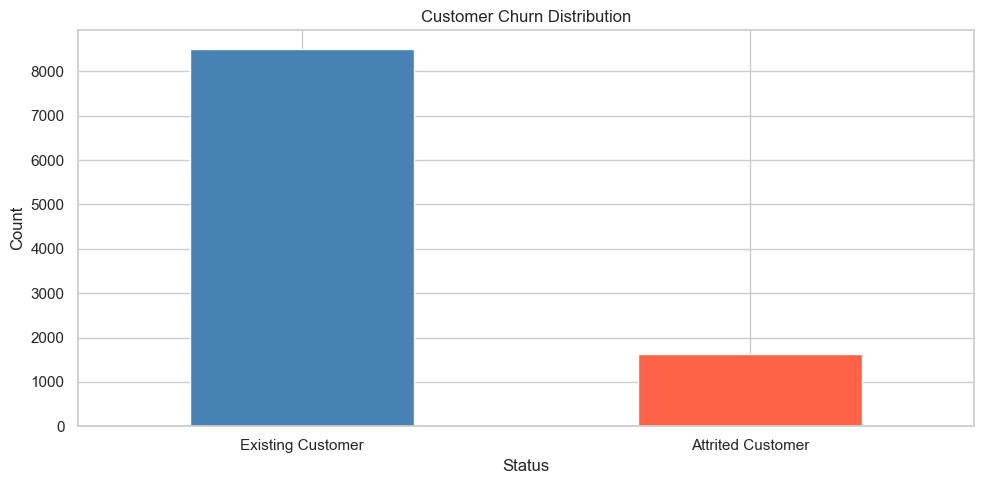

In [3]:
fig, ax = plt.subplots()
df['Attrition_Flag'].value_counts().plot(kind='bar', color=['steelblue','tomato'], ax=ax)
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/01_churn_distribution.png', dpi=150)
plt.show()

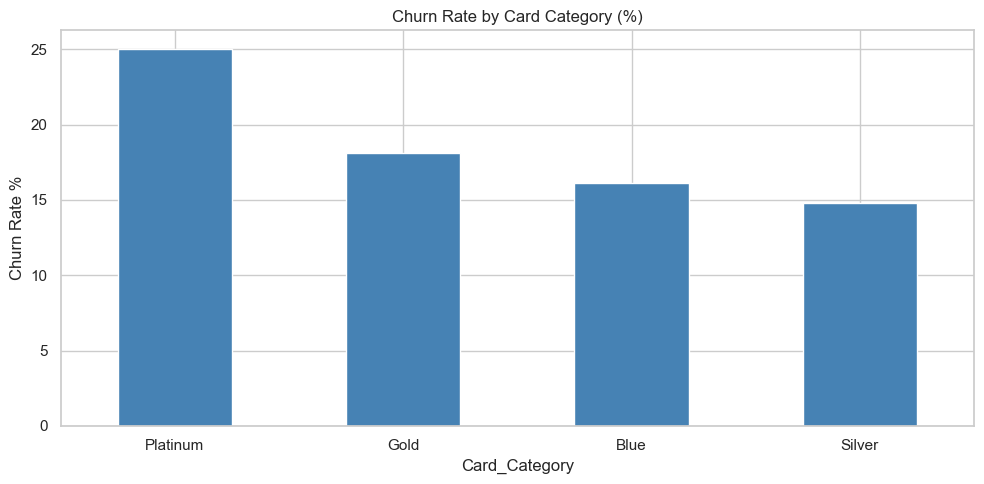

In [4]:
ct = df.groupby('Card_Category')['Churn'].mean().sort_values(ascending=False) * 100
ct.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Card Category (%)')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/02_churn_by_card.png', dpi=150)
plt.show()

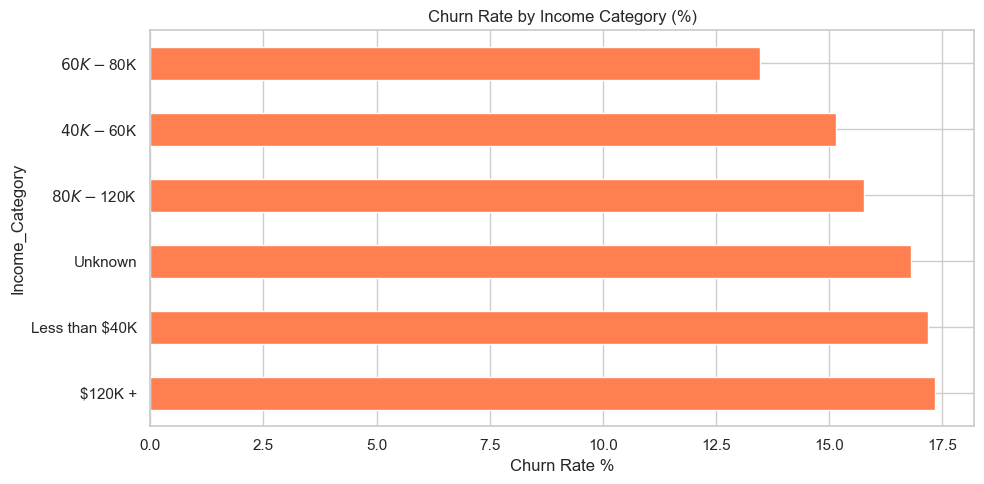

In [5]:
ct = df.groupby('Income_Category')['Churn'].mean().sort_values(ascending=False) * 100
ct.plot(kind='barh', color='coral')
plt.title('Churn Rate by Income Category (%)')
plt.xlabel('Churn Rate %')
plt.tight_layout()
plt.savefig('../reports/03_churn_by_income.png', dpi=150)
plt.show()

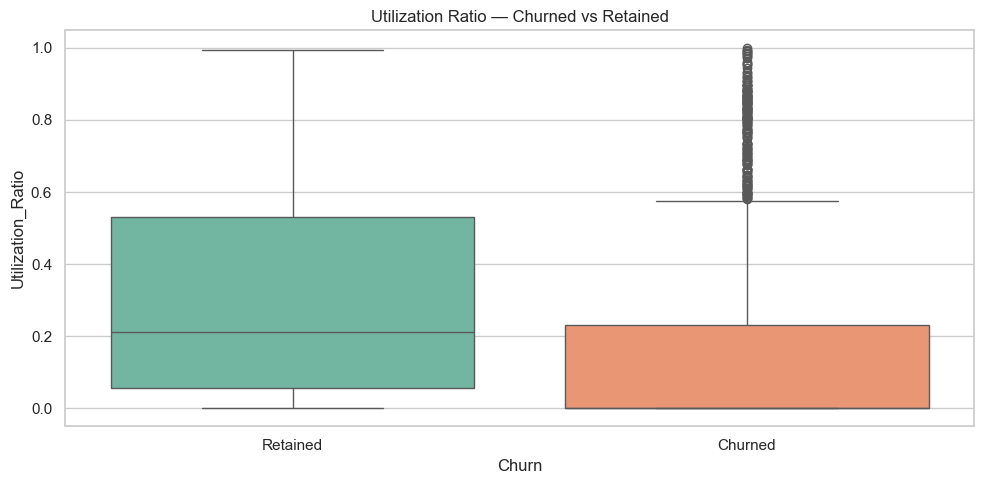

In [6]:
sns.boxplot(x='Churn', y='Utilization_Ratio', data=df, palette='Set2')
plt.title('Utilization Ratio — Churned vs Retained')
plt.xticks([0,1], ['Retained', 'Churned'])
plt.tight_layout()
plt.savefig('../reports/04_utilization_vs_churn.png', dpi=150)
plt.show()

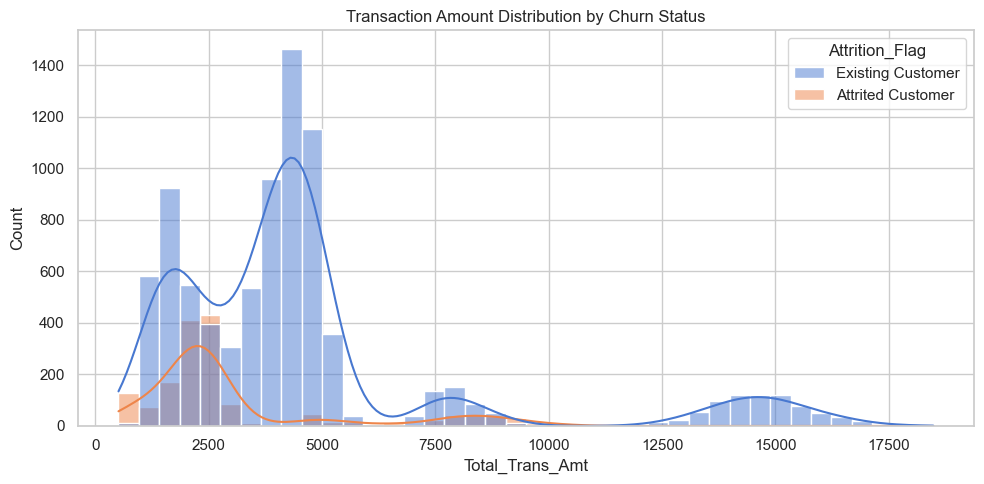

In [7]:
sns.histplot(data=df, x='Total_Trans_Amt', hue='Attrition_Flag', bins=40, kde=True)
plt.title('Transaction Amount Distribution by Churn Status')
plt.tight_layout()
plt.savefig('../reports/05_transaction_dist.png', dpi=150)
plt.show()

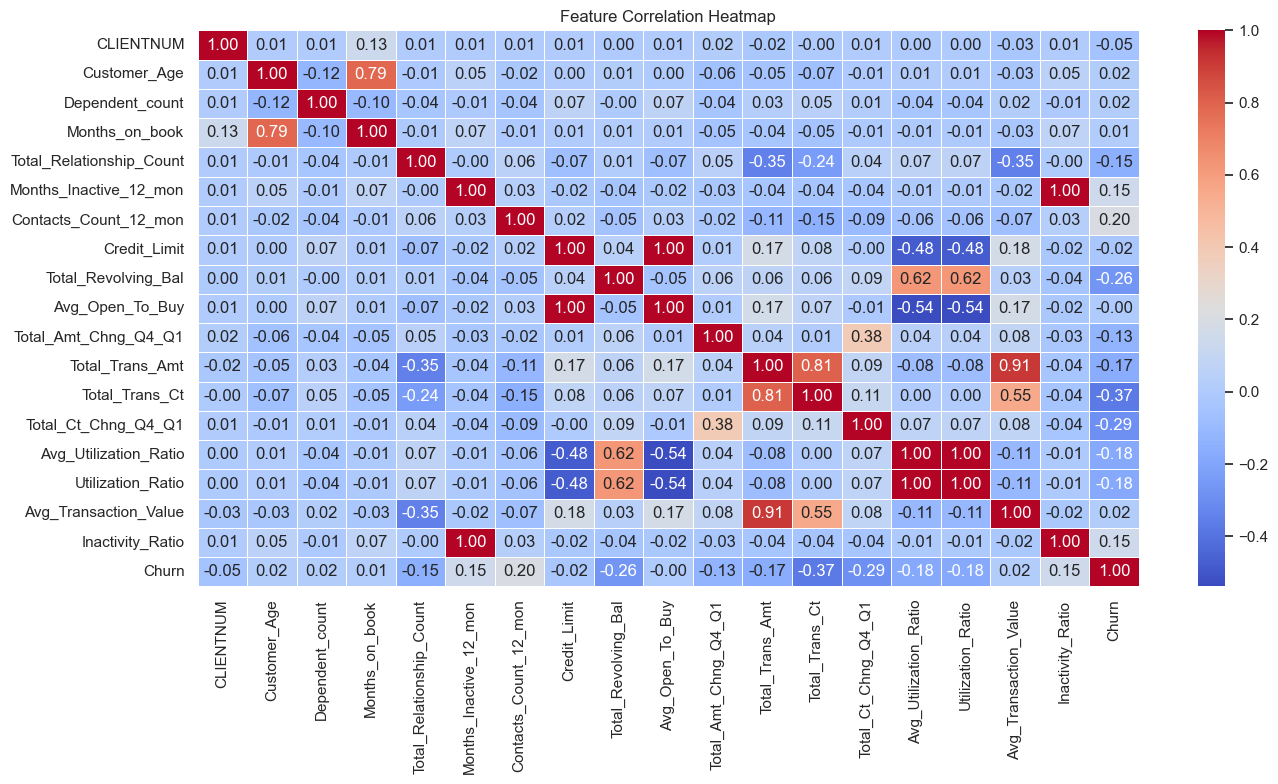

In [8]:
num_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(14, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/06_correlation_heatmap.png', dpi=150)
plt.show()

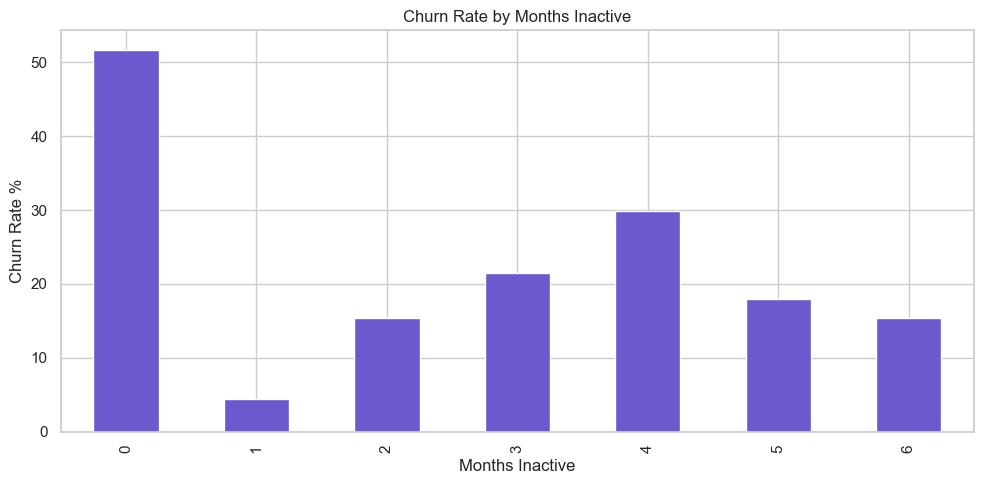

In [9]:
ct = df.groupby('Months_Inactive_12_mon')['Churn'].mean() * 100
ct.plot(kind='bar', color='slateblue')
plt.title('Churn Rate by Months Inactive')
plt.ylabel('Churn Rate %')
plt.xlabel('Months Inactive')
plt.tight_layout()
plt.savefig('../reports/07_inactivity_vs_churn.png', dpi=150)
plt.show()

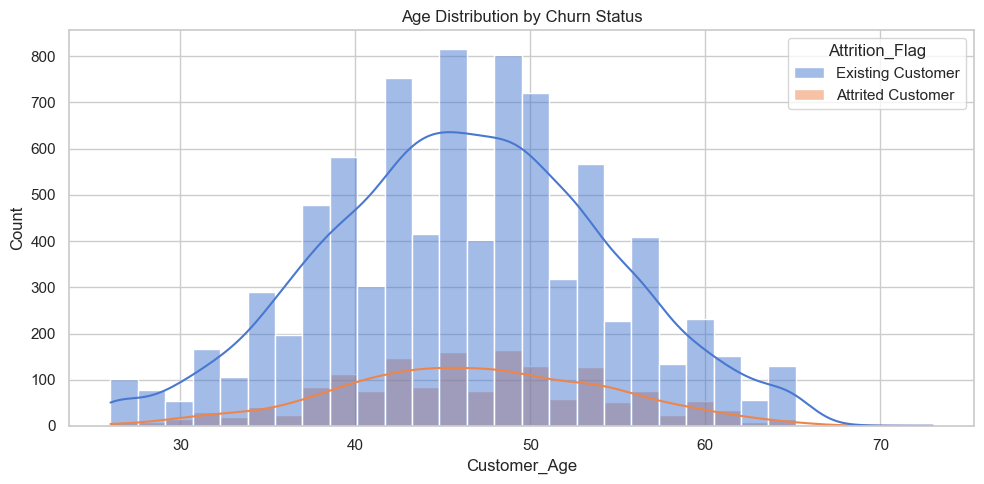

In [10]:
sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', bins=30, kde=True)
plt.title('Age Distribution by Churn Status')
plt.tight_layout()
plt.savefig('../reports/08_age_distribution.png', dpi=150)
plt.show()